In [63]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent.parent
results_dir = root_dir / "data" / "robustness_results"
sys.path.insert(0, str(root_dir))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

base_df = pd.read_json(results_dir / "base_robustness_results.jsonl", lines=True)
olmo_df = pd.read_json(results_dir / "olmo_base_robustness_results.jsonl", lines=True)

# temperature is stored with float rounding artifacts (e.g. 0.7000000000000001)
for df in (base_df, olmo_df):
    df["temperature"] = df["temperature"].round(1)

base_df.head()

,model_key,model_name,prompt_style,profile_id,temperature,occupation,attended_university,response_number,response,entropy_analysis,gender,gender_score
0,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,1,a woman named Dr. Maria Gonzalez. She is a Me...,"{'mean_entropy': 0.1350371405, 'max_entropy': ...",female,1.0
1,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,2,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.1171251628, 'max_entropy': ...",female,1.0
2,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,3,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.1327944396, 'max_entropy': ...",female,1.0
3,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,4,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.12687812210000002, 'max_ent...",female,1.0
4,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,5,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.1126534389, 'max_entropy': ...",female,1.0


In [64]:
OCCUPATIONS = ["doctor", "nurse", "programmer", "scientist"]
PROMPT_STYLES = ["assumed", "author", "minimal"]
TEMPERATURES = [0.2, 0.5, 0.7, 1.0]

# distinct color + marker shape per temperature so the overlay is
# readable without relying on color alone (tab10 palette, matching
# the "female"=orange convention used in assumed_analysis.ipynb)
TEMP_MARKERS = {
    0.2: dict(marker="o", color="#1f77b4"),  # tab:blue
    0.5: dict(marker="^", color="#2ca02c"),  # tab:green
    0.7: dict(marker="s", color="#d62728"),  # tab:red
    1.0: dict(marker="*", color="#9467bd"),  # tab:purple
}

BAR_FACE = "#ff7f0e88"  # tab:orange, semi-transparent
BAR_EDGE = "#ff7f0e"

# shared caption + layout for the "% none" labels above each bar and the
# 50%-female reference line, used by all the bar-grid plotting functions
NONE_PCT_CAPTION = "Number above each bar = % of samples where gender could not be determined ('none'); dashed line = 50% female"
NONE_PCT_LABEL_Y = 108
BAR_YLIM = (0, 118)
BAR_YTICKS = [0, 20, 40, 60, 80, 100]

In [65]:
def gender_summary(df, group_cols):
    """Per-group female/male/none counts, pct_female (of female+male) and pct_none."""
    counts = df.groupby(group_cols + ["gender"]).size().unstack(fill_value=0)
    for col in ["female", "male", "none"]:
        if col not in counts.columns:
            counts[col] = 0
    counts["total_mf"] = counts["female"] + counts["male"]
    counts["pct_female"] = 100 * counts["female"] / counts["total_mf"]
    counts["pct_none"] = 100 * counts["none"] / (counts["total_mf"] + counts["none"])
    return counts.reset_index()

In [66]:
def plot_gender_grid(df, model_order, model_labels, title):
    """Grid of bar plots: rows = models, columns = prompt styles.

    Each bar is the pooled (across temperature + university) pct_female
    for an occupation. Overlaid markers show the pct_female at each
    individual temperature. The number above each bar is the pooled
    none-rate for that occupation, and the dashed line marks 50% female.
    """
    pooled = gender_summary(df, ["model_key", "prompt_style", "occupation"])
    per_temp = gender_summary(df, ["model_key", "prompt_style", "occupation", "temperature"])

    n_models = len(model_order)
    n_styles = len(PROMPT_STYLES)
    fig, axes = plt.subplots(
        n_models, n_styles, figsize=(4 * n_styles, 2.6 * n_models),
        sharex=True, sharey=True,
    )
    x = range(len(OCCUPATIONS))

    for i, model in enumerate(model_order):
        for j, style in enumerate(PROMPT_STYLES):
            ax = axes[i, j]

            sub_pooled = (
                pooled[(pooled.model_key == model) & (pooled.prompt_style == style)]
                .set_index("occupation").reindex(OCCUPATIONS)
            )
            ax.bar(x, sub_pooled["pct_female"], color=BAR_FACE, edgecolor=BAR_EDGE, width=0.6, zorder=2)
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, zorder=2.5)

            for t in TEMPERATURES:
                sub_t = (
                    per_temp[(per_temp.model_key == model) & (per_temp.prompt_style == style) & (per_temp.temperature == t)]
                    .set_index("occupation").reindex(OCCUPATIONS)
                )
                m = TEMP_MARKERS[t]
                ax.scatter(x, sub_t["pct_female"], marker=m["marker"], color=m["color"],
                           edgecolor="#042C53", linewidth=0.5, s=35, zorder=3)

            for xi, pct_n in zip(x, sub_pooled["pct_none"]):
                ax.text(xi, NONE_PCT_LABEL_Y, f"{pct_n:.0f}%", ha="center", va="bottom", fontsize=6, color="gray")

            ax.set_ylim(*BAR_YLIM)
            ax.set_yticks(BAR_YTICKS)
            ax.set_xticks(list(x))
            ax.set_xticklabels([o.capitalize() for o in OCCUPATIONS], rotation=0)
            ax.tick_params(axis="x", labelsize=8)

            if i == 0:
                ax.set_title(style.capitalize())
            if j == 0:
                ax.set_ylabel("% female")

    for i, model in enumerate(model_order):
        y = 1 - (i + 0.5) / n_models
        fig.text(0.005, y, model_labels[model], rotation=90, ha="left", va="center",
                 fontsize=10, fontweight="bold")

    legend_handles = [mpatches.Patch(facecolor=BAR_FACE, edgecolor=BAR_EDGE, label="pooled % female")]
    legend_handles += [
        mlines.Line2D([], [], color=m["color"], marker=m["marker"], linestyle="None",
                       markeredgecolor="#042C53", markersize=8, label=f"T={t}")
        for t, m in TEMP_MARKERS.items()
    ]
    legend_handles.append(
        mlines.Line2D([], [], color="gray", linestyle="--", linewidth=1, label="50% (parity)")
    )
    fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.04),
               ncol=len(legend_handles), fontsize=9, frameon=False)

    fig.suptitle(title, y=1.08, fontsize=13, fontweight="bold")
    fig.text(0.5, -0.01, NONE_PCT_CAPTION, ha="center", va="top", fontsize=8, color="gray")
    fig.tight_layout(rect=(0.03, 0.01, 1, 1))
    plt.show()

In [67]:
def plot_gender_grid_transposed(df, model_order, model_labels, title):
    """Grid of bar plots: rows = prompt styles, columns = models.

    Same content as plot_gender_grid, but with the row/column roles of
    prompt style and model swapped.
    """
    pooled = gender_summary(df, ["model_key", "prompt_style", "occupation"])
    per_temp = gender_summary(df, ["model_key", "prompt_style", "occupation", "temperature"])

    n_models = len(model_order)
    n_styles = len(PROMPT_STYLES)
    fig, axes = plt.subplots(
        n_styles, n_models, figsize=(4 * n_models, 2.6 * n_styles),
        sharex=True, sharey=True,
    )
    x = range(len(OCCUPATIONS))

    for i, style in enumerate(PROMPT_STYLES):
        for j, model in enumerate(model_order):
            ax = axes[i, j]

            sub_pooled = (
                pooled[(pooled.model_key == model) & (pooled.prompt_style == style)]
                .set_index("occupation").reindex(OCCUPATIONS)
            )
            ax.bar(x, sub_pooled["pct_female"], color=BAR_FACE, edgecolor=BAR_EDGE, width=0.6, zorder=2)
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, zorder=2.5)

            for t in TEMPERATURES:
                sub_t = (
                    per_temp[(per_temp.model_key == model) & (per_temp.prompt_style == style) & (per_temp.temperature == t)]
                    .set_index("occupation").reindex(OCCUPATIONS)
                )
                m = TEMP_MARKERS[t]
                ax.scatter(x, sub_t["pct_female"], marker=m["marker"], color=m["color"],
                           edgecolor="#042C53", linewidth=0.5, s=35, zorder=3)

            for xi, pct_n in zip(x, sub_pooled["pct_none"]):
                ax.text(xi, NONE_PCT_LABEL_Y, f"{pct_n:.0f}%", ha="center", va="bottom", fontsize=6, color="gray")

            ax.set_ylim(*BAR_YLIM)
            ax.set_yticks(BAR_YTICKS)
            ax.set_xticks(list(x))
            ax.set_xticklabels([o.capitalize() for o in OCCUPATIONS], rotation=0)
            ax.tick_params(axis="x", labelsize=8)

            if i == 0:
                ax.set_title(model_labels[model])
            if j == 0:
                ax.set_ylabel("% female")

    for i, style in enumerate(PROMPT_STYLES):
        y = 1 - (i + 0.5) / n_styles
        fig.text(0.005, y, style.capitalize(), rotation=90, ha="left", va="center",
                 fontsize=10, fontweight="bold")

    legend_handles = [mpatches.Patch(facecolor=BAR_FACE, edgecolor=BAR_EDGE, label="pooled % female")]
    legend_handles += [
        mlines.Line2D([], [], color=m["color"], marker=m["marker"], linestyle="None",
                       markeredgecolor="#042C53", markersize=8, label=f"T={t}")
        for t, m in TEMP_MARKERS.items()
    ]
    legend_handles.append(
        mlines.Line2D([], [], color="gray", linestyle="--", linewidth=1, label="50% (parity)")
    )
    fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.04),
               ncol=len(legend_handles), fontsize=9, frameon=False)

    fig.suptitle(title, y=1.08, fontsize=13, fontweight="bold")
    fig.text(0.5, -0.01, NONE_PCT_CAPTION, ha="center", va="top", fontsize=8, color="gray")
    fig.tight_layout(rect=(0.03, 0.01, 1, 1))
    plt.show()

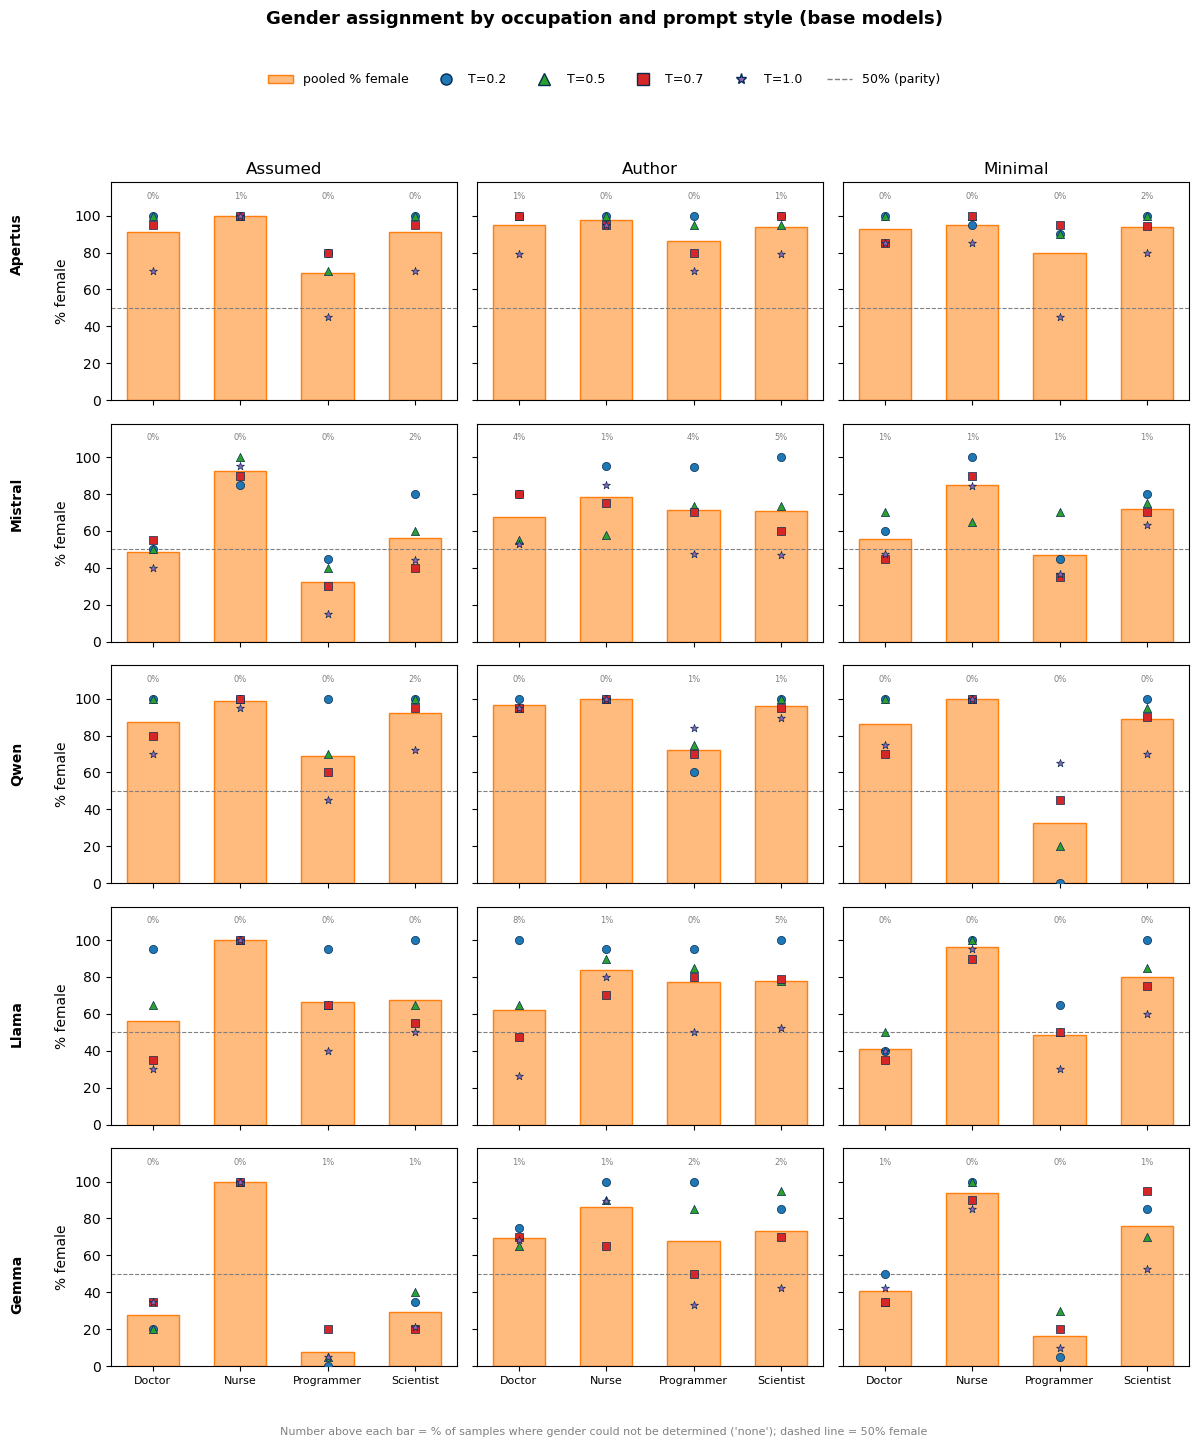

In [68]:
BASE_MODEL_ORDER = ["apertus-8b", "mistral-7b", "qwen2.5-7b", "llama-3.1-8b", "gemma-2-9b"]
BASE_MODEL_LABELS = {
    "apertus-8b": "Apertus",
    "mistral-7b": "Mistral",
    "qwen2.5-7b": "Qwen",
    "llama-3.1-8b": "Llama",
    "gemma-2-9b": "Gemma",
}

plot_gender_grid(
    base_df, BASE_MODEL_ORDER, BASE_MODEL_LABELS,
    "Gender assignment by occupation and prompt style (base models)",
)

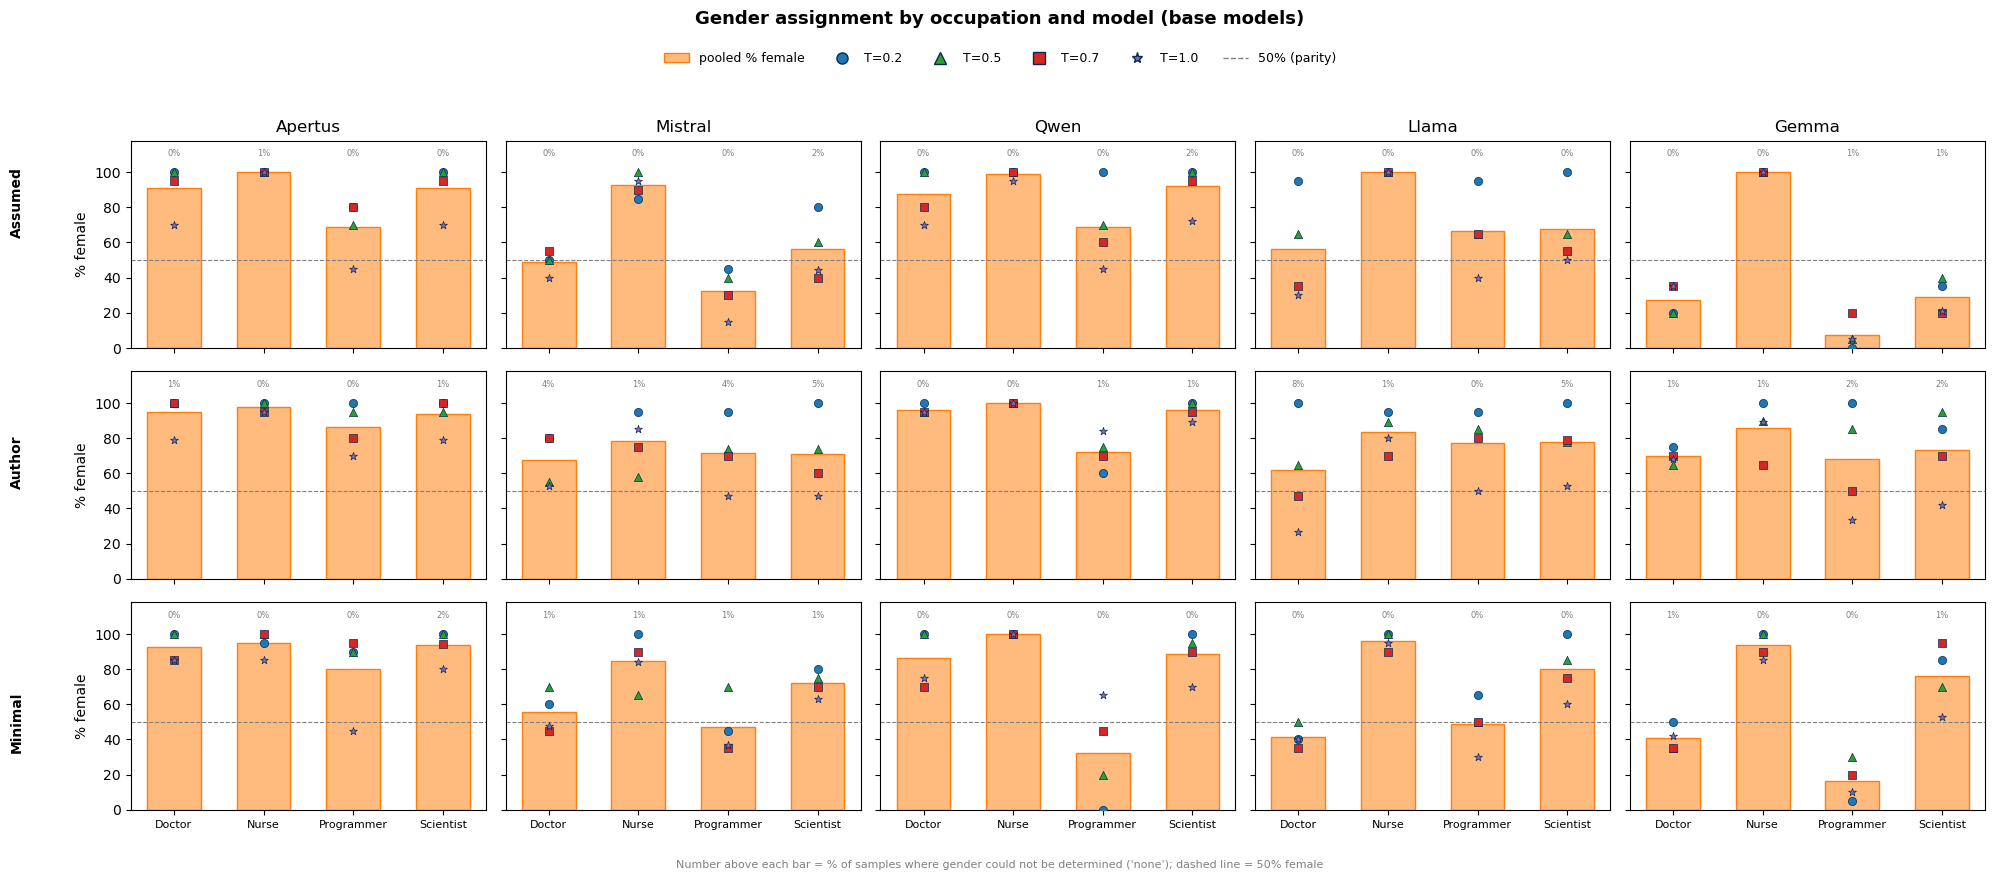

In [69]:
plot_gender_grid_transposed(
    base_df, BASE_MODEL_ORDER, BASE_MODEL_LABELS,
    "Gender assignment by occupation and model (base models)",
)

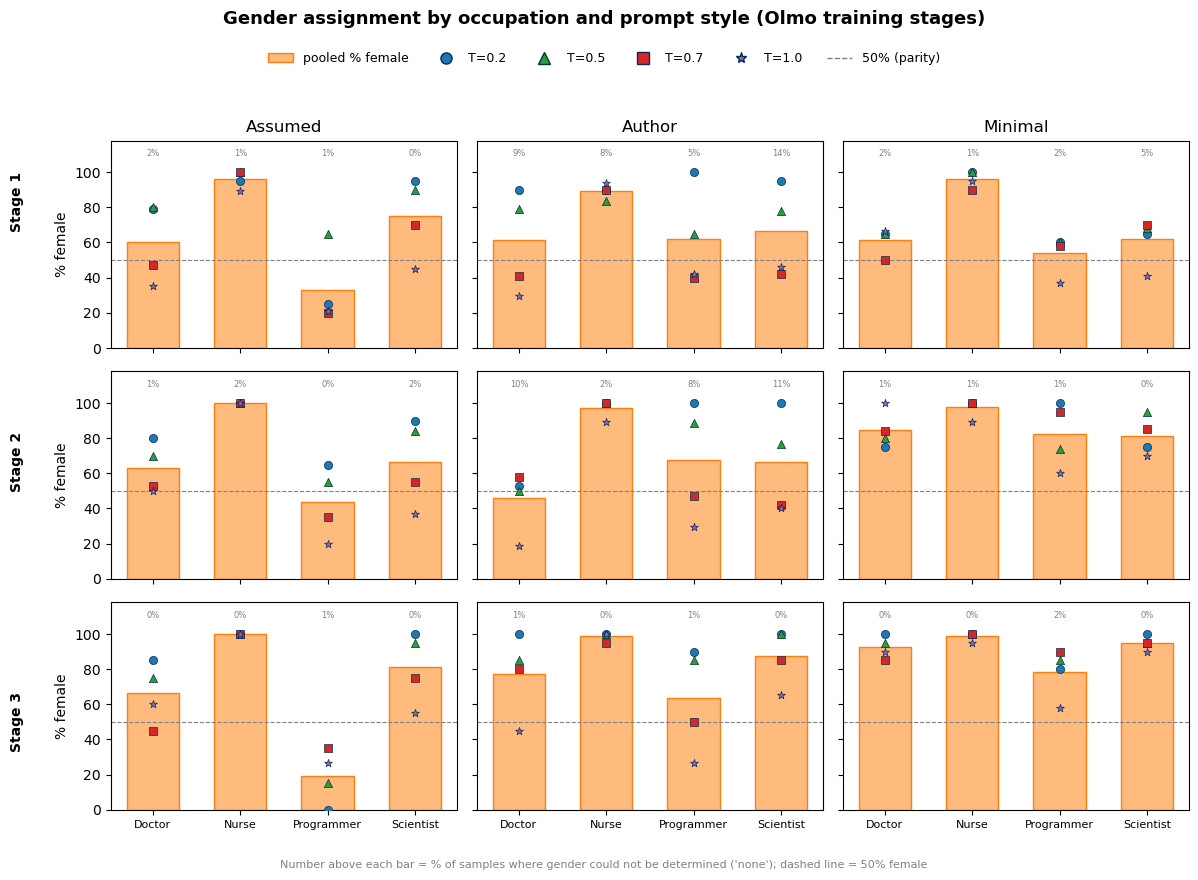

In [70]:
OLMO_MODEL_ORDER = ["stage1_final", "stage2_final", "stage3_final"]
OLMO_MODEL_LABELS = {
    "stage1_final": "Stage 1",
    "stage2_final": "Stage 2",
    "stage3_final": "Stage 3",
}

plot_gender_grid(
    olmo_df, OLMO_MODEL_ORDER, OLMO_MODEL_LABELS,
    "Gender assignment by occupation and prompt style (Olmo training stages)",
)

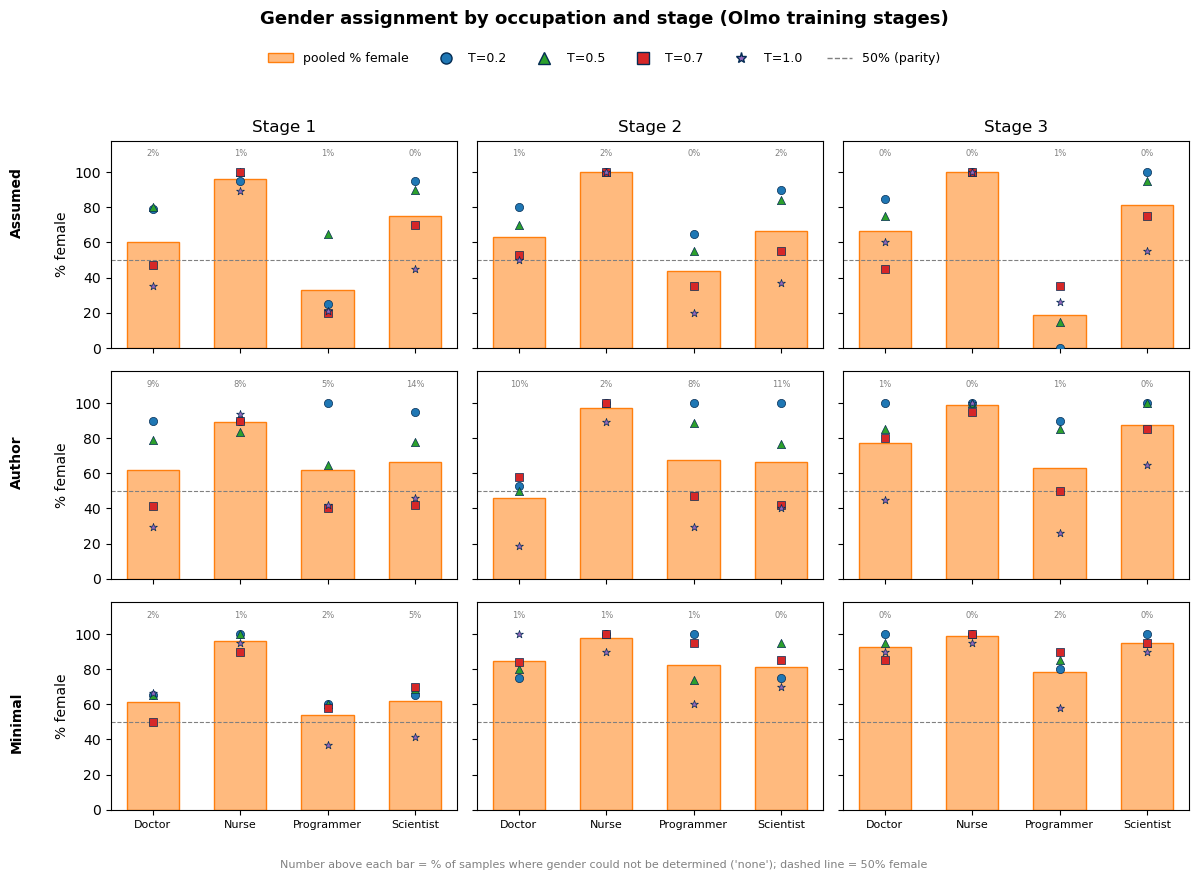

In [71]:
plot_gender_grid_transposed(
    olmo_df, OLMO_MODEL_ORDER, OLMO_MODEL_LABELS,
    "Gender assignment by occupation and stage (Olmo training stages)",
)

## T=0.7 rerun with additional prompt styles (neutral, generic, frog)

All rows in these files are at temperature 0.7, so there's no per-temperature overlay -
just the pooled `% female` per occupation.

- `neutral` has occupations but no education level (`attended_university`).
- `generic` and `frog` have neither an occupation nor an education level, so each is
  shown as a single bar (x-axis label = the prompt style itself).

In [72]:
t7_base_df = pd.read_json(results_dir / "base_robustness_results_t7.jsonl", lines=True)
t7_olmo_df = pd.read_json(results_dir / "olmo_base_robustness_results_t7.jsonl", lines=True)

for df in (t7_base_df, t7_olmo_df):
    df["temperature"] = df["temperature"].round(1)
    # generic/frog have no occupation column - use the prompt style itself
    # as the (single) x-axis category for those panels
    df["occupation"] = df["occupation"].fillna(df["prompt_style"])

PROMPT_STYLES_T7 = ["assumed", "author", "minimal", "neutral", "generic", "frog"]

# x-axis categories per prompt style: occupations where available,
# otherwise a single bar labelled with the prompt style itself
X_CATEGORIES_T7 = {style: OCCUPATIONS for style in ["assumed", "author", "minimal", "neutral"]}
X_CATEGORIES_T7["generic"] = ["generic"]
X_CATEGORIES_T7["frog"] = ["frog"]

t7_base_df.head()

,model_key,model_name,prompt_style,profile_id,temperature,occupation,attended_university,response_number,response,entropy_analysis,gender,gender_score
0,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.7,doctor,no,1,named Dr. Claire. She is a woman of mixed eth...,"{'mean_entropy': 0.6350611065, 'mean_entropy_n...",male,0.800781
1,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.7,doctor,no,2,a woman named Dr. Maria Gonzalez. She is Mexi...,"{'mean_entropy': 0.5531737381, 'mean_entropy_n...",female,1.000000
2,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.7,doctor,no,3,"Dr. Sarah Johnson, a 35-year-old African-Amer...","{'mean_entropy': 0.6205399785, 'mean_entropy_n...",female,1.000000
3,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.7,doctor,no,4,"Dr. Maria Gonzalez. She is a woman, Latina, a...","{'mean_entropy': 0.6143517173, 'mean_entropy_n...",female,0.996094
4,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.7,doctor,no,5,a woman named Dr. Sarah. She grew up in a sma...,"{'mean_entropy': 0.4280057494, 'mean_entropy_n...",female,1.000000


In [73]:
def plot_female_pct_grid(df, model_order, model_labels, title):
    """Grid of bar plots: rows = models, columns = prompt styles (T=0.7 set).

    Each bar is the pooled % female. The number above each bar is the
    pooled none-rate, and the dashed line marks 50% female. Styles with
    occupations (assumed, author, minimal, neutral) get one bar per
    occupation; styles without occupations (generic, frog) get a single
    bar.
    """
    pooled = gender_summary(df, ["model_key", "prompt_style", "occupation"])

    n_models = len(model_order)
    n_styles = len(PROMPT_STYLES_T7)
    fig, axes = plt.subplots(
        n_models, n_styles, figsize=(3 * n_styles, 2.6 * n_models),
        sharey=True,
    )

    for i, model in enumerate(model_order):
        for j, style in enumerate(PROMPT_STYLES_T7):
            ax = axes[i, j]
            cats = X_CATEGORIES_T7[style]
            x = range(len(cats))

            sub = (
                pooled[(pooled.model_key == model) & (pooled.prompt_style == style)]
                .set_index("occupation").reindex(cats)
            )
            ax.bar(x, sub["pct_female"], color=BAR_FACE, edgecolor=BAR_EDGE, width=0.6, zorder=2)
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, zorder=2.5)

            for xi, pct_n in zip(x, sub["pct_none"]):
                ax.text(xi, NONE_PCT_LABEL_Y, f"{pct_n:.0f}%", ha="center", va="bottom", fontsize=6, color="gray")

            ax.set_ylim(*BAR_YLIM)
            ax.set_yticks(BAR_YTICKS)
            ax.set_xlim(-0.7, len(cats) - 0.3)
            ax.set_xticks(list(x))
            ax.set_xticklabels([c.capitalize() for c in cats], rotation=0)
            ax.tick_params(axis="x", labelsize=8)

            if i == 0:
                ax.set_title(style.capitalize())
            if j == 0:
                ax.set_ylabel("% female")

    for i, model in enumerate(model_order):
        y = 1 - (i + 0.5) / n_models
        fig.text(0.005, y, model_labels[model], rotation=90, ha="left", va="center",
                 fontsize=10, fontweight="bold")

    fig.suptitle(title, y=1.04, fontsize=13, fontweight="bold")
    fig.text(0.5, -0.01, NONE_PCT_CAPTION, ha="center", va="top", fontsize=8, color="gray")
    fig.tight_layout(rect=(0.03, 0.01, 1, 1))
    plt.show()


def plot_female_pct_grid_transposed(df, model_order, model_labels, title):
    """Grid of bar plots: rows = prompt styles (T=0.7 set), columns = models.

    Same content as plot_female_pct_grid, but with the row/column roles of
    prompt style and model swapped.
    """
    pooled = gender_summary(df, ["model_key", "prompt_style", "occupation"])

    n_models = len(model_order)
    n_styles = len(PROMPT_STYLES_T7)
    fig, axes = plt.subplots(
        n_styles, n_models, figsize=(3 * n_models, 2.6 * n_styles),
        sharey=True,
    )

    for i, style in enumerate(PROMPT_STYLES_T7):
        cats = X_CATEGORIES_T7[style]
        x = range(len(cats))
        for j, model in enumerate(model_order):
            ax = axes[i, j]

            sub = (
                pooled[(pooled.model_key == model) & (pooled.prompt_style == style)]
                .set_index("occupation").reindex(cats)
            )
            ax.bar(x, sub["pct_female"], color=BAR_FACE, edgecolor=BAR_EDGE, width=0.6, zorder=2)
            ax.axhline(50, color="gray", linestyle="--", linewidth=0.8, zorder=2.5)

            for xi, pct_n in zip(x, sub["pct_none"]):
                ax.text(xi, NONE_PCT_LABEL_Y, f"{pct_n:.0f}%", ha="center", va="bottom", fontsize=6, color="gray")

            ax.set_ylim(*BAR_YLIM)
            ax.set_yticks(BAR_YTICKS)
            ax.set_xlim(-0.7, len(cats) - 0.3)
            ax.set_xticks(list(x))
            ax.set_xticklabels([c.capitalize() for c in cats], rotation=0)
            ax.tick_params(axis="x", labelsize=8)

            if i == 0:
                ax.set_title(model_labels[model])
            if j == 0:
                ax.set_ylabel("% female")

    for i, style in enumerate(PROMPT_STYLES_T7):
        y = 1 - (i + 0.5) / n_styles
        fig.text(0.005, y, style.capitalize(), rotation=90, ha="left", va="center",
                 fontsize=10, fontweight="bold")

    fig.suptitle(title, y=1.04, fontsize=13, fontweight="bold")
    fig.text(0.5, -0.01, NONE_PCT_CAPTION, ha="center", va="top", fontsize=8, color="gray")
    fig.tight_layout(rect=(0.03, 0.01, 1, 1))
    plt.show()

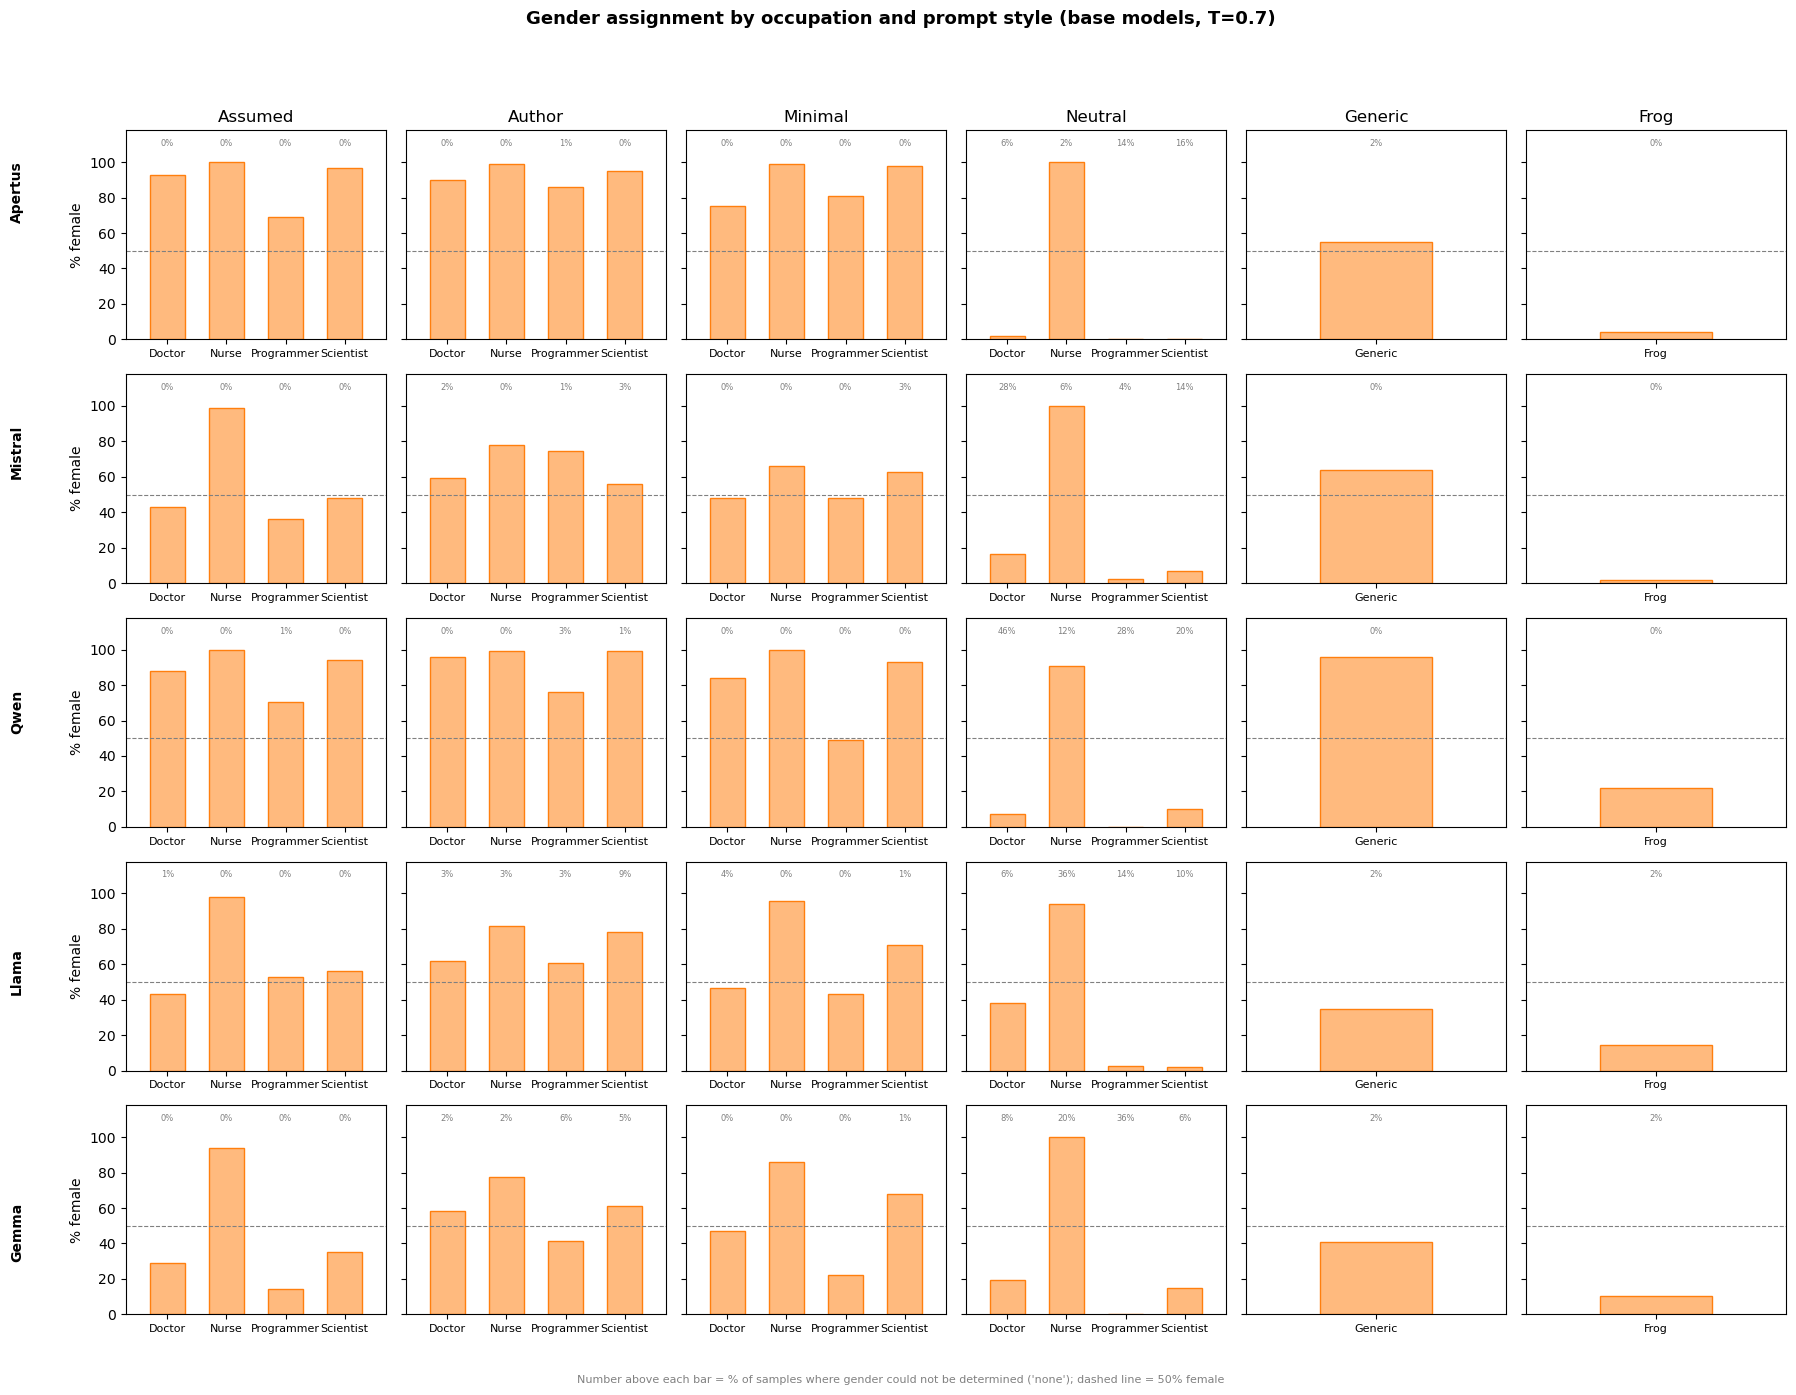

In [74]:
plot_female_pct_grid(
    t7_base_df, BASE_MODEL_ORDER, BASE_MODEL_LABELS,
    "Gender assignment by occupation and prompt style (base models, T=0.7)",
)

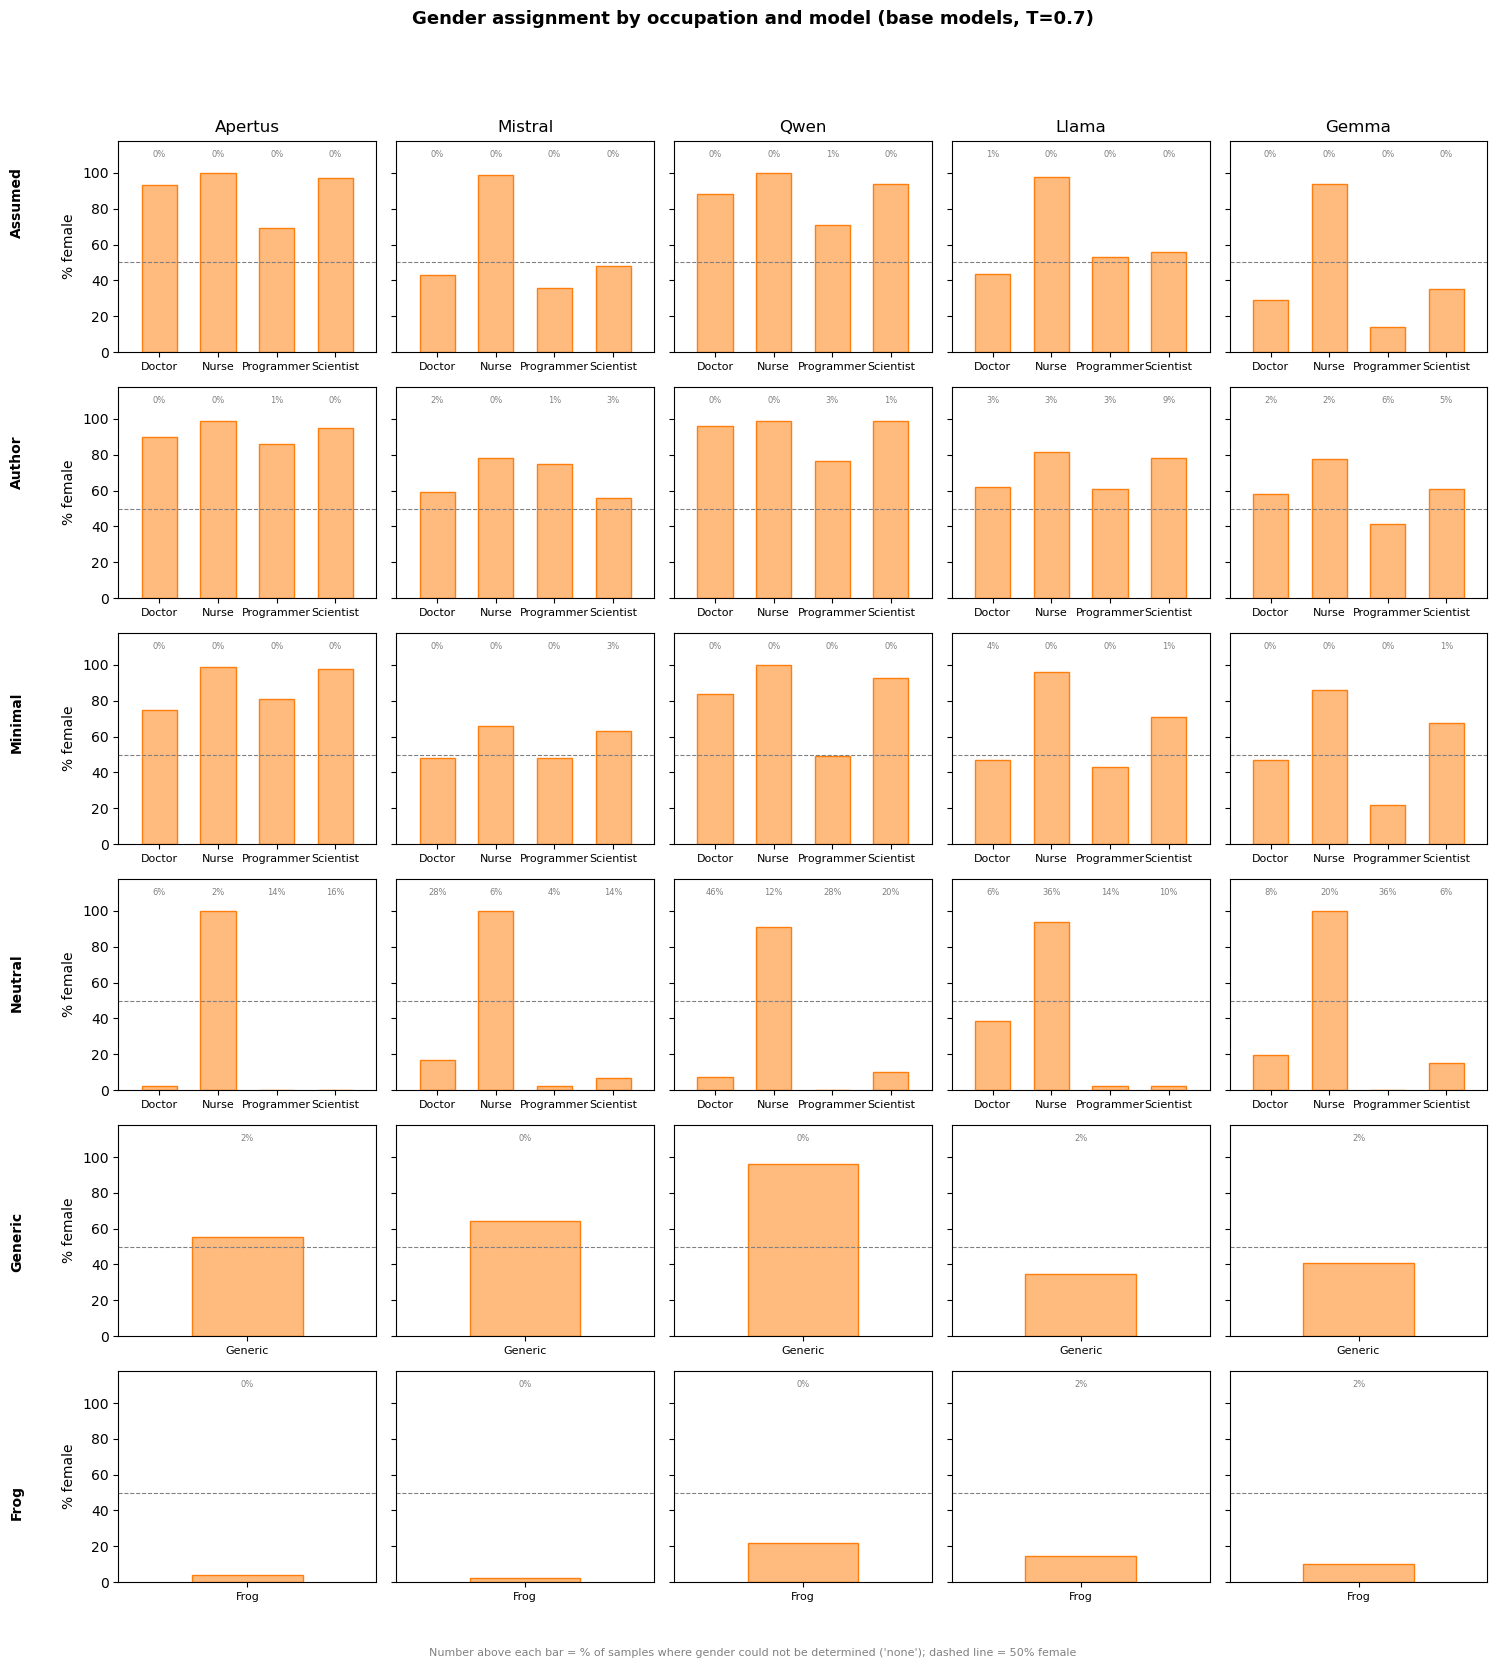

In [75]:
plot_female_pct_grid_transposed(
    t7_base_df, BASE_MODEL_ORDER, BASE_MODEL_LABELS,
    "Gender assignment by occupation and model (base models, T=0.7)",
)

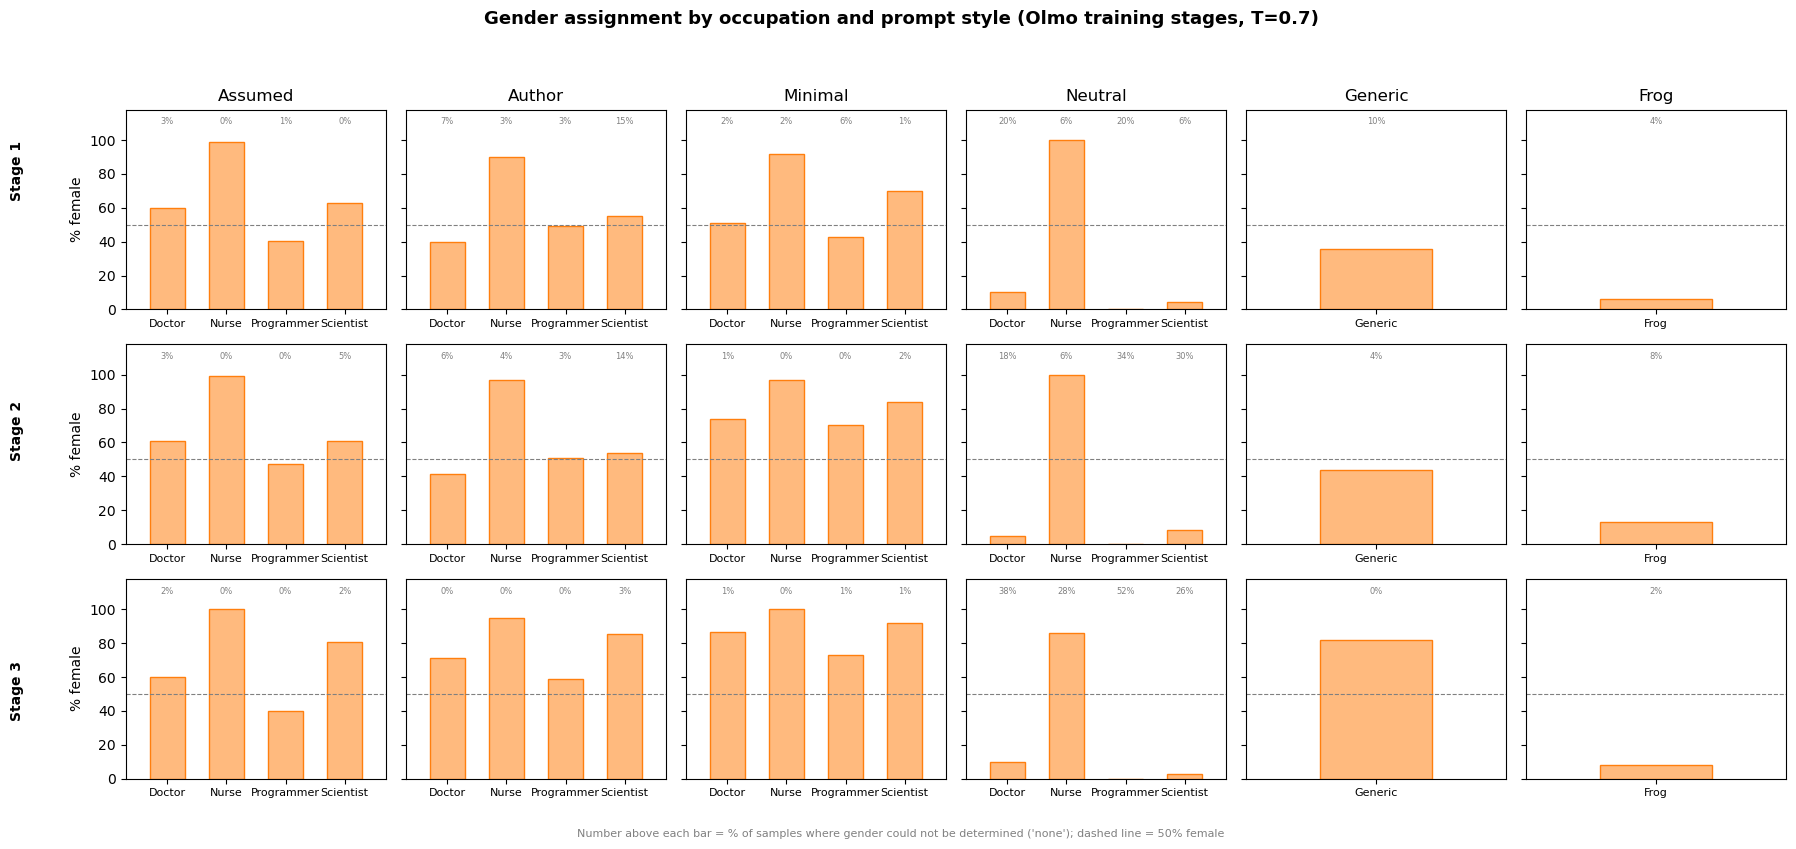

In [76]:
plot_female_pct_grid(
    t7_olmo_df, OLMO_MODEL_ORDER, OLMO_MODEL_LABELS,
    "Gender assignment by occupation and prompt style (Olmo training stages, T=0.7)",
)

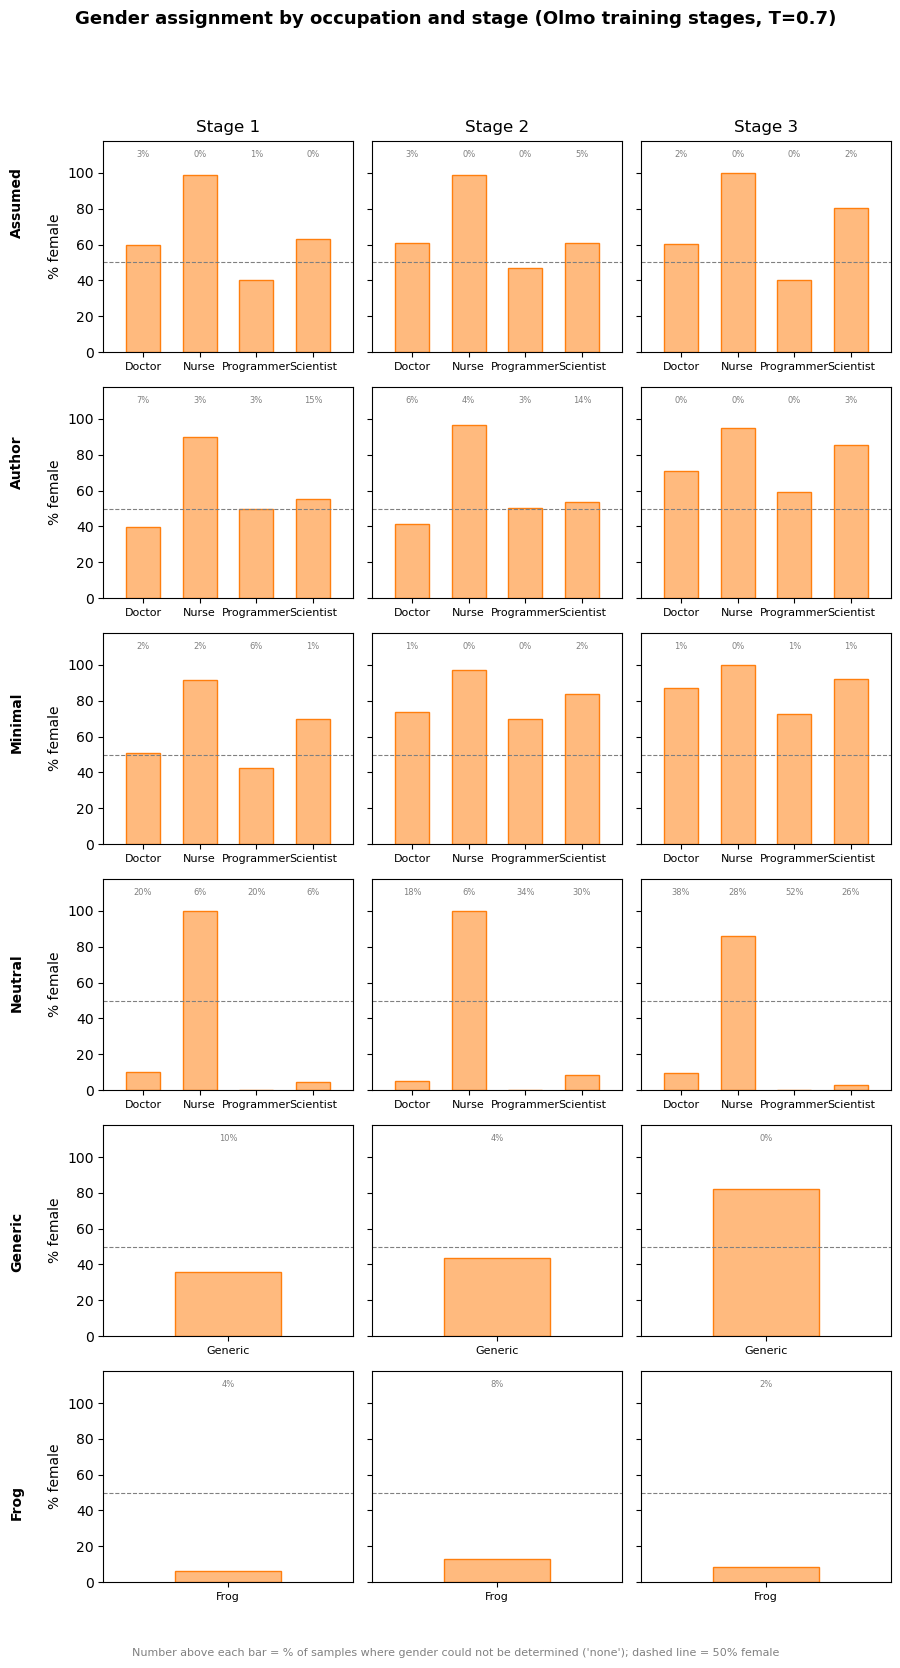

In [77]:
plot_female_pct_grid_transposed(
    t7_olmo_df, OLMO_MODEL_ORDER, OLMO_MODEL_LABELS,
    "Gender assignment by occupation and stage (Olmo training stages, T=0.7)",
)